In [1]:
### Function Three

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

In [3]:
X = np.load("function_3/initial_inputs.npy")

# new rows
X = np.append(X, [
    [0.151800, 0.439900, 0.990900],
    [0.000015, 0.999999, 0.999999],
    [0.651221, 0.411593, 0.540176],
    [0.626529, 0.211593, 0.424070],
    [0.851221, 0.211593, 0.740176],
    [0.851221, 0.611593, 0.504938],
    [0.959595, 0.811593, 0.399509],
    [0.900000, 0.811593, 0.495554],
    [0.851221, 0.611593, 0.504938],
    [0.851221, 0.611593, 0.504938],
    [0.851221, 0.611593, 0.504938],
    	[0.905408, 0.711593, 0.452223]
              ],axis=0)

In [4]:
y= np.load("function_3/initial_outputs.npy")

# new rows
y = np.append(y, [-0.4108942135308994,
                  -0.501755912728561,
                  -0.033527902763252126,
                  -0.03769506935981549,
                  -0.1378589116427748,	
                  -0.013537192340862855,
                  	-0.02342642243954806,
                  -0.03198731461075479,
                  -0.02978517151201847,
                  -0.004686647016489443,
                  -0.027952721141016657,
                  -0.012108937983944516,
                  -0.006974822969405832
                 
                 ], axis=0)

In [5]:
max(y)

-0.004686647016489443

In [45]:
X


array([[1.71525207e-01, 3.43916870e-01, 2.48737201e-01],
       [2.42114461e-01, 6.44074270e-01, 2.72432809e-01],
       [5.34905720e-01, 3.98500915e-01, 1.73388729e-01],
       [4.92581415e-01, 6.11593188e-01, 3.40176386e-01],
       [1.34621666e-01, 2.19917240e-01, 4.58206220e-01],
       [3.45523271e-01, 9.41359831e-01, 2.69363479e-01],
       [1.51836632e-01, 4.39990619e-01, 9.90881867e-01],
       [6.45502835e-01, 3.97142940e-01, 9.19771338e-01],
       [7.46911945e-01, 2.84196309e-01, 2.26299855e-01],
       [1.70476994e-01, 6.97032401e-01, 1.49169434e-01],
       [2.20549337e-01, 2.97825244e-01, 3.43555344e-01],
       [6.66013659e-01, 6.71985151e-01, 2.46295297e-01],
       [4.68089497e-02, 2.31360241e-01, 7.70617592e-01],
       [6.00097282e-01, 7.25135725e-01, 6.60886415e-02],
       [9.65994849e-01, 8.61119690e-01, 5.66829131e-01],
       [1.51800000e-01, 4.39900000e-01, 9.90900000e-01],
       [1.50000000e-05, 9.99999000e-01, 9.99999000e-01],
       [6.51221000e-01, 4.11593

In [46]:
y

array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
       -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
       -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837,
       -0.41089421, -0.50175591, -0.0335279 , -0.03769507, -0.13785891,
       -0.01353719, -0.02342642, -0.03198731, -0.02978517, -0.00468665,
       -0.02795272])

In [47]:
max(y)

-0.004686647016489443

In [48]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Define the Kernel
# Matern(nu=1.5) is a good balance between smooth and rugged.
# nu=2.5 would be smoother; nu=0.5 would be very "jagged".
# WhiteKernel handles "noise" in your observations.
kernel = 1.0 * Matern(length_scale=[1.0, 1.0, 1.0], 
                      length_scale_bounds=(1e-2, 1e2), 
                      nu=1.5) + WhiteKernel(noise_level=1e-5)

# 2. Initialize the model
# n_restarts_optimizer=10 is crucial. It runs the tuning 10 times from 
# different starting points to find the best length scales.
model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=20, 
    alpha=1e-1  # Value for numerical stability
)

# 3. Fit to your data
# inputs: your (18, 3) array
# outputs: your (18,) array
model.fit(X, y)

# Now you can use model.predict(X_new, return_std=True) in your EI function

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the spe

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * Matern...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.1
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Gl

In [49]:
from scipy.stats import norm

def expected_improvement(x_new, model, current_best_y, xi=10):
    x_new = x_new.reshape(1, -1)
    mu, sigma = model.predict(x_new, return_std=True)
    
    # Ensure sigma is a scalar for the comparison
    sigma = sigma.flatten()[0]
    mu = mu.flatten()[0]

    if sigma <= 0:
        return 0.0
    
    # ADDED XI HERE: 
    # Instead of (mu - current_best_y), we use (mu - current_best_y - xi)
    improvement = mu - current_best_y - xi
    z = improvement / sigma
    
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    
    return -ei

# 2. Get your current maximum value (closest to zero)
current_best_y = np.max(y) 

# 3. Optimize
x0 = X[np.argmax(y)]
res = minimize(expected_improvement, x0, 
               bounds=[(0, 1), (0, 1), (0, 1)], 
               args=(model, current_best_y))

next_point = res.x

In [50]:
print(next_point)

[0.851221 0.611593 0.504938]


In [51]:
# Current best point: [0.492, 0.611, 0.340]
x_best = X[np.argmax(y)]

# Create a local "box" around the best point (e.g., +/- 0.2 in each direction)
local_bounds = [(0, 1), (0, 1), (0, 1)]

res = minimize(expected_improvement, x_best, 
               bounds=local_bounds, 
               args=(model, current_best_y))

next_point = res.x
print(next_point)

[0.851221 0.611593 0.504938]


In [52]:
# Third inputs
# UCB and EI kept suggesting unexplored regions of the universe
# Kept EI but localised the bounds within the three known peaks, the suggested inputs were more promising of execution

In [53]:
local_bounds

[(0, 1), (0, 1), (0, 1)]

In [54]:
def upper_confidence_bound(x_test, kappa=10):
    """
    UCB Acquisition Function
    kappa=2.576 corresponds to a 99% confidence interval.
    Common values: 1.0 (exploitative) to 5.0+ (exploratory).
    """
    mu, sigma = model.predict(x_test.reshape(1, -1), return_std=True)
    
    # UCB Formula
    ucb = mu + kappa * sigma
    
    # Return NEGATIVE because 'minimize' will find the highest score
    return -ucb

In [55]:
# # UCB
def get_next_candidate(model, bounds, kappa=10, n_restarts=40):
    best_x = None
    min_ucb = float('inf')
    
    # We run the optimizer from multiple random starting points 
    # to ensure we find the true maximum of the UCB function.
    for starting_point in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, 3)):
        res = minimize(
            fun=upper_confidence_bound,
            x0=starting_point,
            args=(kappa,),
            bounds=bounds,
            method='L-BFGS-B'
        )
        
        if res.fun < min_ucb:
            min_ucb = res.fun
            best_x = res.x
            
    return best_x

# Define your 4D bounds (assuming 0 to 1 based on your data)
bounds = np.array([[0, 1], [0, 1], [0, 1]])

# Get the next point to sample
next_x = get_next_candidate(model, bounds, kappa=100) # High kappa to find peaks
next_point = next_x
print(f"Next point to sample: {next_x}")

Next point to sample: [0. 0. 1.]


In [56]:
# logic for PI

#def probability_of_improvement(x_new, model, current_best_y):
#     x_new = x_new.reshape(1, -1)
#     mu, sigma = model.predict(x_new, return_std=True)
#     if sigma <= 0: return 0.0
    
#     z = (mu - current_best_y) / sigma
#     # We want to maximize the probability, so we negate it for 'minimize'
#     return -norm.cdf(z)

In [57]:
import torch
# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))


positive_indices = [3,4,10,13,17,18,19,20]
y_labels[positive_indices] = 1

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

# Labels: Indices 4, 9, 10, 11, 12 as 1, rest as 0
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

In [58]:
# Deep layer

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(3, 10),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(10, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [60]:
# Clear gradients and do a fresh pass for saliency
X_tensor.grad.zero_()
output = model(X_tensor)
output.backward(torch.ones_like(output))

# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 1.1840
 1    | 0.0255
 2    | 1.5865
 3    | 1.9041
 4    | 1.6883
 5    | 0.0012
 6    | 0.8676
 7    | 1.1728
 8    | 1.3220
 9    | 0.0000
10    | 1.6660
11    | 1.9222
12    | 2.0168
13    | 2.0393
14    | 0.5669
15    | 0.8679
16    | 0.0026
17    | 1.9984
18    | 1.5892
19    | 2.0435
20    | 1.5110
21    | 1.0683
22    | 0.8384
23    | 1.5110
24    | 1.5110
25    | 1.5110


In [61]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.5100
Predicted Class: 1


/var/folders/b1/jr7k43v1395g6gvnq7gz_qq80000gn/T/ipykernel_4697/1102642691.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  sample_input = torch.tensor([next_point], dtype=torch.float32)


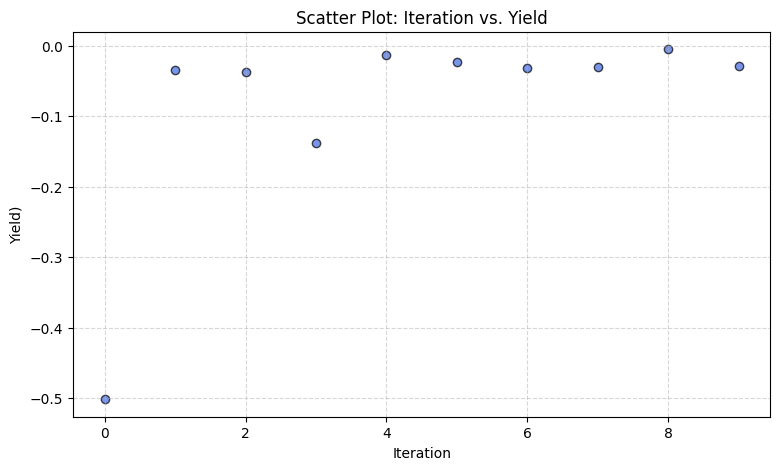

In [62]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0,10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 3. Customization
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()